## Extract database

In [42]:
#import kagglehub

# Download if the dataset is not already downloaded & if exists in the cache, it will return the path to the dataset files
#path = kagglehub.dataset_download("shivamb/netflix-shows")

#print("Path to dataset files:", path)

In [43]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

## Load database

In [44]:
DATA_PATH = Path("/Users/miftahhadiyannoor/.cache/kagglehub/datasets/shivamb/netflix-shows/versions/5")

# Load database
df = pd.read_csv(DATA_PATH / "netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [45]:
# Understand the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Task from Kaggle

### 1. Understanding what content is available in different countries
### 2. Identifying similar content by matching text-based features
### 3. Network analysis of Actors / Directors and find interesting insights
### 4. Does Netflix has more focus on TV Shows than movies in recent years.

In [46]:
print("Missing values summary")
print(df.isnull().sum())

Missing values summary
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


## Handle missing values

In [47]:
# Fill missing values with appropritate strategies
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['date_added'].fillna(method='ffill', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna(df['duration'].mode()[0], inplace=True)

# Verify missing values have been filled
print("\nMissing values summary after filling:")
print(df.isnull().sum())


Missing values summary after filling:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Feature engineering: Convert Date and add year column

In [49]:
df['date_added'] = pd.to_datetime(df['date_added'].astype("string").str.strip(), format="mixed", errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("Date range:", df['date_added'].min(), "to", df['date_added'].max())
df[['title', 'date_added', 'year_added']].head()

Date range: 2008-01-01 00:00:00 to 2021-09-25 00:00:00


,title,date_added,year_added
0,Dick Johnson Is Dead,2021-09-25,2021
1,Blood & Water,2021-09-24,2021
2,Ganglands,2021-09-24,2021
3,Jailbirds New Orleans,2021-09-24,2021
4,Kota Factory,2021-09-24,2021


## Task 1 - Understandng Content by Country
* ### Split countries and explode to individual countries

In [50]:
df_countries = df['country'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)
df_countries.name = 'country_single'
df_expanded = df.drop('country', axis=1).join(df_countries)

# Top 10 countries by content
top_countries = df_expanded['country_single'].value_counts().head(10)
print("Top 10 countries by content:")
print(top_countries)

Top 10 countries by content:
country_single
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


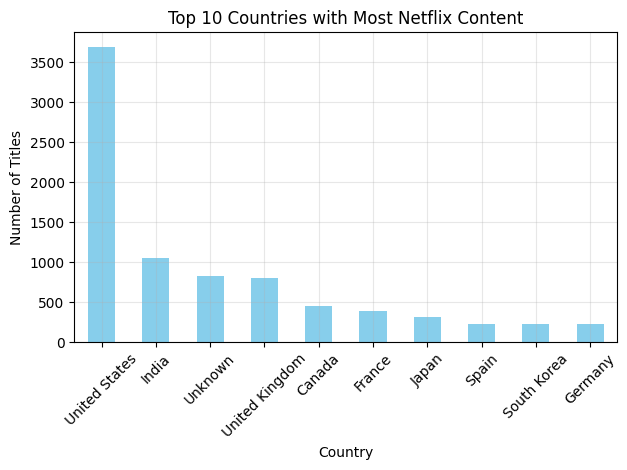

In [ ]:
# Country distribution plot visualization
plt.Figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries with Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Content Type Distribution by Top Countries:
type            Movie  TV Show
country_single                
United States    2751      938
India             962       84
Unknown           440      391
United Kingdom    532      272
Canada            319      126
France            303       90
Japan             119      199
Spain             171       61
South Korea        61      170
Germany           182       44


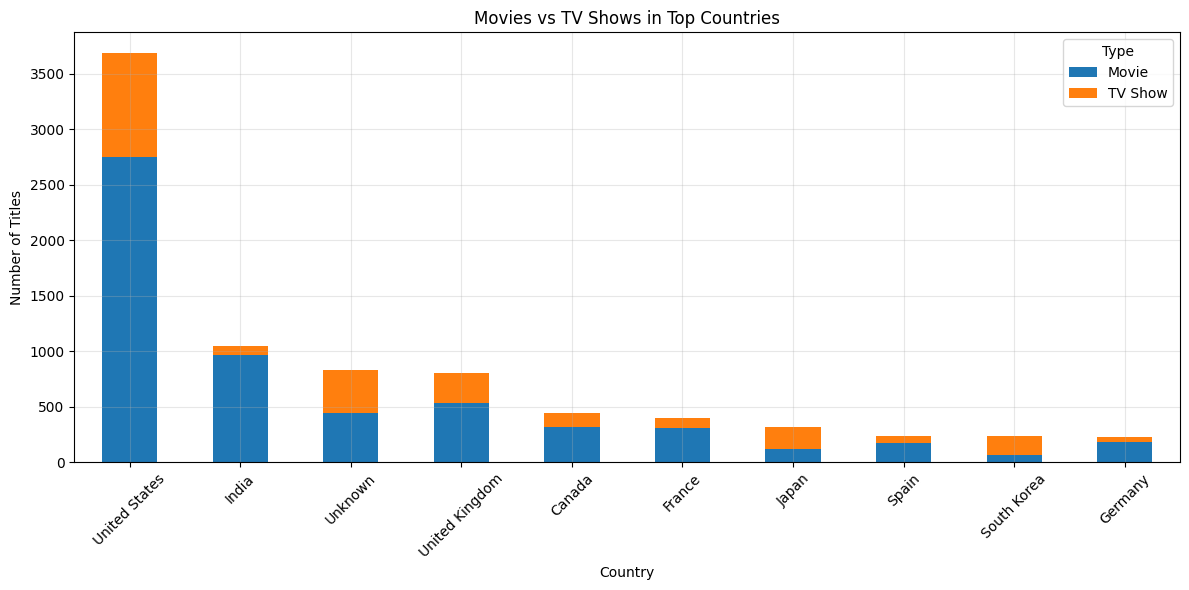

In [52]:
# Content type distribution by Top countries
country_type = df_expanded.groupby(['country_single', 'type']).size().unstack(fill_value=0)
country_type_top = country_type.loc[top_countries.index]
print("\nContent Type Distribution by Top Countries:")
print(country_type_top)

# Visualization
country_type_top.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Movies vs TV Shows in Top Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Taksk 2 - Similar Content by Text Features
* ### Combine text features

In [57]:
def combine_text_features(row):
    """Combined text features for content-based filtering."""
    features = []

    if row['director'] != 'Unknown':
        features.append(row['director'])
    if row['cast'] != 'Unknown':
        features.append(row['cast'])
    if row['listed_in'] != 'Unknown':
        features.append(row['listed_in'])
    if row['description'] != 'Unknown':
        features.append(row['description'])
    return ' '.join(features)

df['combined_features'] = df.apply(combine_text_features, axis=1)
print("Combined features for the first 5 rows:")
print(df[['title', 'combined_features']].head())

Combined features for the first 5 rows:
                   title                                  combined_features
0   Dick Johnson Is Dead  Kirsten Johnson Documentaries As her father ne...
1          Blood & Water  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2              Ganglands  Julien Leclercq Sami Bouajila, Tracy Gotoas, S...
3  Jailbirds New Orleans  Docuseries, Reality TV Feuds, flirtations and ...
4           Kota Factory  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...


In [64]:
# create TF-IDF Vectors
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['combined_features'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (8807, 5000)


In [65]:
# Calculate cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Similarity Matrix Shape: {cosine_sim.shape}")

Similarity Matrix Shape: (8807, 8807)


## Find Similar Content

In [81]:
# Function to Find Similar Content
def find_similar_content(title, df, cosine_sim, n=5):
    """Find n similar content based on the title"""
    try:
        idx = df[df['title'] == title].index[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores  = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:n+1]  # Exclude the first one
        similar_indices = [i[0] for i in sim_scores]
        similar_df = df.iloc[similar_indices][['title', 'type', 'director', 'cast']]
        similar_df['similarity_score'] = [score for _, score in sim_scores]
        return similar_df
    except IndexError:
        return f"Title '{title}' not found in the dataset."

# Apply the function to find similar 5 content for a given title
sample_title = df['title'].iloc[0]
print(f"Finding similar content for: {sample_title}")
find_similar_content(sample_title, df, cosine_sim, n=5)

Finding similar content for: Dick Johnson Is Dead


,title,type,director,cast,similarity_score
2350,Woodshock,Movie,"Kate Mulleavy, Laura Mulleavy","Kirsten Dunst, Joe Cole, Pilou Asbæk, Jack Kil...",0.235456
7015,How to Be a Player,Movie,Lionel C. Martin,"Bill Bellamy, Natalie Desselle, Lark Voorhies,...",0.207891
7454,Midnight Special,Movie,Jeff Nichols,"Michael Shannon, Joel Edgerton, Kirsten Dunst,...",0.175804
5233,The Death and Life of Marsha P. Johnson,Movie,David France,Unknown,0.175396
6553,Daffedar,Movie,Johnson Esthappan,"Tini Tom, Malavikka, Sudheer Karamana, Indrans",0.171306


In [82]:
# Test similarity on another title
test_title = df[df['type'] == 'TV Show']['title'].iloc[0]
print(f"\nContent similar to '{test_title}':")
find_similar_content(test_title, df, cosine_sim)


Content similar to 'Blood & Water':


,title,type,director,cast,similarity_score
5388,46,TV Show,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",0.224491
1654,Before 30,TV Show,BB Sasore,"Damilola Adegbite, O.C. Ukeje, Beverly Naya, M...",0.196697
5038,Re:Mind,TV Show,Unknown,Keyakizaka46,0.187894
3684,Kakegurui,TV Show,Unknown,"Minami Hamabe, Mahiro Takasugi, Aoi Morikawa",0.185200
5324,20 Minutes,TV Show,Unknown,"Tuba Büyüküstün, Ilker Aksum, Bülent Emin Yara...",0.181694


## Task 3 - Network Analysis

In [85]:
def create_network(df):
    """Create network graph connecting directors to actors"""
    G = nx.Graph()

    for _, row in df.iterrows():
        if row['director'] != 'Unknown' and row['cast'] != 'Unknown':
            director = row['director']
            actors = row['cast'].split(', ')

            if director not in G:
                G.add_node(director, type='director', content_count=1)
            else:
                G.nodes[director]['content_count'] += 1

            for actor in actors:
                if actor not in G:
                    G.add_node(actor, type='actor', content_count=1)
                else:
                    G.nodes[actor]['content_count'] += 1
                G.add_edge(director, actor)

    return G

G = create_network(df)
print("\nNetwork Statistics:")
print(f"Nodes (Directors + Actors): {G.number_of_nodes()}")
print(f"Edges (Collaborations): {G.number_of_edges()}")


Network Statistics:
Nodes (Directors + Actors): 30496
Edges (Collaborations): 43087
